In [1]:
import os
import cv2
import ast
import numpy as np
from tqdm import tqdm
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.optim import lr_scheduler

import pytorch_lightning as pl
import segmentation_models_pytorch as smp

In [2]:
MODEL_NAME = "deeplabv3plus" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d" 
DEVICE_ID = 2
EPOCHS = 100
LEARNING_RATE = 3e-4
BATCH_SIZE = 128
IMAGE_SIZE = 320
SEED = 42

In [3]:
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/fish-vista' # Define the Fish-Vista dataset directory

# Load the segmentation splits and check the shape
seg_train_csv = os.path.join(DATA_DIR, r'segmentation_train.csv')
seg_val_csv = os.path.join(DATA_DIR, r'segmentation_val.csv')
seg_test_csv = os.path.join(DATA_DIR, r'segmentation_test.csv')
seg_train_df = pd.read_csv(seg_train_csv)
seg_val_df = pd.read_csv(seg_val_csv)
seg_test_df = pd.read_csv(seg_test_csv)
print(f'Shape of FishVista segmentation datasets,  train: {seg_train_df.shape}, validation: {seg_val_df.shape}, test): {seg_test_df.shape}')
print(f'Columns of the test dataset:', list(seg_test_df.columns))

# Class labels of the segmentation split
train_species = set(list(seg_train_df['standardized_species']))
val_species = set(list(seg_val_df['standardized_species']))
test_species = set(list(seg_test_df['standardized_species']))
check_val = [v for v in val_species if v not in train_species]
check_test = [v for v in test_species if v not in train_species]
print(f'The number of classes (species) are, train: {len(train_species)}, val: {len(val_species)}, test: {len(test_species)}')
print(f'Species in val but not train: {len(check_val)},  species in test but not train: {len(check_test)}')

# Read the mask labels (traits)
seg_json_path = os.path.join(DATA_DIR, 'segmentation_masks', 'seg_id_trait_map.json')
with open(seg_json_path, 'r') as json_file:
    content = json_file.read()
    seg_json = ast.literal_eval(content)
    print('Names of the mask labels (traits):')
    print(seg_json)
labels = list(seg_json.values())

Shape of FishVista segmentation datasets,  train: (4312, 11), validation: (316, 11), test): (1504, 11)
Columns of the test dataset: ['index', 'filename', 'source_filename', 'original_format', 'arkid', 'source', 'owner', 'license', 'original_url', 'family', 'standardized_species']
The number of classes (species) are, train: 2586, val: 303, test: 1224
Species in val but not train: 146,  species in test but not train: 639
Names of the mask labels (traits):
{0: 'Background', 1: 'Head', 2: 'Eye', 3: 'Dorsal fin', 4: 'Pectoral fin', 5: 'Pelvic fin', 6: 'Anal fin', 7: 'Caudal fin', 8: 'Adipose fin', 9: 'Barbel'}


In [4]:
def visualize(*, labels=None, **images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    for i, (name, data) in enumerate(images.items(), 1):
        plt.subplot(1, n, i)
        plt.xticks([]); plt.yticks([])
        plt.title(name.replace("_", " ").title(), fontsize=14)
        arr = np.asarray(data)

        # ---------------- IMAGE ----------------
        if name == "image":
            # Handle CHW → HWC
            if arr.ndim == 3 and arr.shape[0] == 3:
                arr = arr.transpose(1, 2, 0)
            # Normalize to 0–1 if needed
            if arr.max() > 1.0:
                arr = arr / 255.0
            plt.imshow(arr)
            continue

        # ---------------- MASK PLOTTING ----------------
        # Supports unlimited integer classes with exact color mapping
        mask = arr.squeeze()  # H x W
        cmap = plt.get_cmap("turbo")  # # Alternatives: "nipy_spectral", "hsv", "jet", "gist_ncar"        
        bounds = np.arange(-0.5, mask.max() + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)
        plt.imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")

        # ---------------- LEGEND ----------------
        # Exact color match between image and legend
        handles = [
            Patch(
                color=cmap(norm(v)),  # exact color used in the image
                label=labels[v] if v < len(labels) else f"Class {v} (unknown)"
            )
            for v in np.unique(mask)
        ]

        plt.legend(
            handles=handles, title="Classes", bbox_to_anchor=(1.05, 1),
            loc="upper left", borderaxespad=0.0, fontsize=10, title_fontsize=12
        )

    plt.tight_layout()
    plt.show()

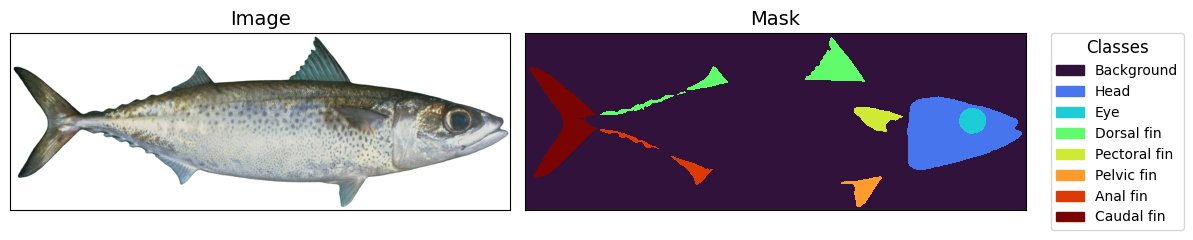

In [5]:
# Original image and mask
sample_img = seg_train_df['filename'][30]
sample_img_path = os.path.join(DATA_DIR, 'Images', sample_img)
sample_img_obj = Image.open(sample_img_path)
sample_mask_path = os.path.join(DATA_DIR, 'segmentation_masks', 'images', sample_img)[:-4]+'.png'
sample_mask_obj = Image.open(sample_mask_path)
visualize(labels=labels, image=sample_img_obj, mask=sample_mask_obj)

In [6]:
class PartWholeDataset(Dataset):
    def __init__(self, image_size=224, data_path=DATA_DIR, df=None):
        self.df = df
        self.image_size = image_size
        self.image_dir = os.path.join(data_path, 'Images')
        self.mask_dir = os.path.join(data_path, 'segmentation_masks', 'images')
        self.image_names = list(self.df['filename']) # os.listdir(self.image_dir)
        # self.image_paths = [os.path.join(self.image_dir, p) for p in self.image_names]

        # transform for image
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                interpolation=transforms.InterpolationMode.NEAREST
            ),
            transforms.PILToTensor(),  # keeps integer values
        ])
    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # Load the image at index idx and convert to tensor
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        img_pil = Image.open(img_path)
        img_tens = self.img_transform(img_pil)

        # Load the corresponding mask and convert to tensor
        mask_path = os.path.join(self.mask_dir, img_name)[:-4]+'.png'
        mask_pil = Image.open(mask_path)
        mask_tens = self.mask_transform(mask_pil)

        cls_label = self.df['standardized_species'][idx]
        return img_tens, mask_tens.squeeze(0), cls_label

In [7]:
train_dataset = PartWholeDataset(image_size=IMAGE_SIZE, data_path=DATA_DIR, df=seg_train_df)
val_dataset = PartWholeDataset(image_size=IMAGE_SIZE, data_path=DATA_DIR, df=seg_val_df)
test_dataset = PartWholeDataset(image_size=IMAGE_SIZE, data_path=DATA_DIR, df=seg_test_df)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
num_classes = len(labels)
print(f"Training with number of part labels (including background) = {num_classes}")
print("Part labels:", labels)

Train: 4312, Val: 316, Test: 1504
Training with number of part labels (including background) = 10
Part labels: ['Background', 'Head', 'Eye', 'Dorsal fin', 'Pectoral fin', 'Pelvic fin', 'Anal fin', 'Caudal fin', 'Adipose fin', 'Barbel']


class_id: scomber australasicus


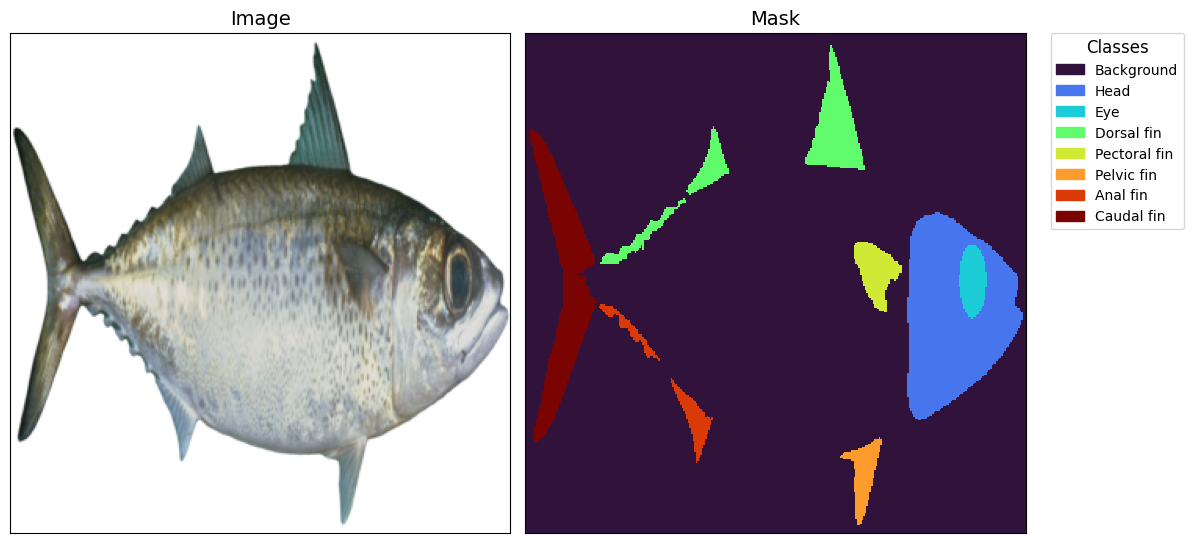

In [8]:
# Get sample image and mask
img, mask, class_id = train_dataset[30]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)

In [9]:
# ---------------------------------------------------
# Image + Mask Transform Function
# ---------------------------------------------------

def apply_transform(img, mask, transform):
    if transform == "rot90":
        img_t = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        mask_t = cv2.rotate(mask, cv2.ROTATE_90_CLOCKWISE)

    elif transform == "rot180":
        img_t = cv2.rotate(img, cv2.ROTATE_180)
        mask_t = cv2.rotate(mask, cv2.ROTATE_180)

    elif transform == "rot270":
        img_t = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
        mask_t = cv2.rotate(mask, cv2.ROTATE_90_COUNTERCLOCKWISE)

    elif transform == "flip_h":
        img_t = cv2.flip(img, 1)
        mask_t = cv2.flip(mask, 1)

    elif transform == "flip_v":
        img_t = cv2.flip(img, 0)
        mask_t = cv2.flip(mask, 0)

    else:
        img_t = img.copy()
        mask_t = mask.copy()

    return img_t, mask_t

# ---------------------------------------------------
# Overlay Mask Visualization
# ---------------------------------------------------

def overlay_mask(img, mask, alpha=0.5):
    """
    Overlay segmentation mask on image.
    Works for multi-class masks.
    """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    colored_mask = np.zeros_like(img_rgb)

    unique_vals = np.unique(mask)

    for val in unique_vals:
        if val == 0:
            continue  # background

        color = np.random.randint(0, 255, 3)
        colored_mask[mask == val] = color

    overlay = cv2.addWeighted(img_rgb, 1, colored_mask, alpha, 0)
    return overlay

def to_numpy_image(img):
    """
    Convert PIL / Tensor / numpy image to RGB uint8 numpy (H,W,3)
    """
    if isinstance(img, Image.Image):
        img = np.array(img)
    elif torch.is_tensor(img):
        img = img.detach().cpu()
        # If (C,H,W) → (H,W,C)
        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = img.permute(1, 2, 0)
        # If float in [0,1] → convert to uint8 properly
        if img.dtype == torch.float32 or img.max() <= 1.0:
            img = (img * 255.0).clamp(0, 255)
        img = img.byte().numpy()
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    return img

def to_numpy_mask(mask):
    if isinstance(mask, Image.Image):
        mask = np.array(mask)
    elif torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()
    return mask.astype(np.uint8)

def to_numpy_mask(mask):
    """
    Convert PIL / Tensor / numpy mask to (H,W) numpy array
    """
    if isinstance(mask, Image.Image):
        mask = np.array(mask)

    elif torch.is_tensor(mask):
        mask = mask.detach().cpu()
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        mask = mask.numpy()

    return mask.astype(np.int32)

def visualize_augmentations(img, mask):
    # img = cv2.imread(image_path)
    # mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    img = to_numpy_image(img)
    mask = to_numpy_mask(mask)

    transforms = [
        ("original", None),
        ("rot90", "rot90"),
        ("rot180", "rot180"),
        ("rot270", "rot270"),
        ("flip_h", "flip_h"),
        ("flip_v", "flip_v"),
    ]

    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    for ax, (title, tf) in zip(axs.ravel(), transforms):
        if tf is None:
            img_t, mask_t = img, mask
        else:
            img_t, mask_t = apply_transform(img, mask, tf)

        overlay = overlay_mask(img_t, mask_t)

        ax.imshow(overlay)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def visualize_augmentations_overlay(img_tensor, mask_tensor, labels, alpha=0.45, ncols=3):
    img  = to_numpy_image(img_tensor)           # should be uint8 H×W×3 RGB
    mask = to_numpy_mask(mask_tensor)           # integer H×W

    aug_list = [
        ("original",   None),
        ("rot 90°",    "rot90"),
        ("rot 180°",   "rot180"),
        ("rot 270°",   "rot270"),
        ("flip horiz", "flip_h"),
        ("flip vert",  "flip_v"),
    ]

    nrows = (len(aug_list) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    # Prepare discrete colormap (same as your visualize())
    max_label = int(mask.max()) if mask.size > 0 else 0
    bounds = np.arange(-0.5, max_label + 1.5)
    cmap = plt.get_cmap("turbo")
    norm = BoundaryNorm(bounds, cmap.N)

    legend_handles = [
        Patch(color=cmap(norm(v)), label=labels[int(v)] if int(v) < len(labels) else f"cls {int(v)}")
        for v in sorted(np.unique(mask)) if v > 0
    ]

    for i, (title, tf_name) in enumerate(aug_list):
        ax = axes[i // ncols, i % ncols]

        if tf_name is None:
            img_show, mask_show = img.copy(), mask.copy()
        else:
            img_show, mask_show = apply_transform(img, mask, tf_name)

        # ── Create overlay using NumPy (safe & fast) ─────────────────────────────
        overlay = img_show.astype(np.float32)   # important: go to float for blending

        unique_vals = np.unique(mask_show)
        for v in unique_vals:
            if v == 0:
                continue
            # Get color in [0,1] range
            rgba = cmap(norm(v))                # (r,g,b,a) float [0,1]
            color_rgb = (np.array(rgba[:3]) * 255).astype(np.uint8)

            # Create mask for this class
            class_mask = (mask_show == v)

            # Blend only in those pixels
            overlay[class_mask] = (
                overlay[class_mask] * (1 - alpha) +
                color_rgb * alpha
            )

        # Back to uint8 for display
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)

        ax.imshow(overlay)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            title="Parts",
            loc="center right",
            bbox_to_anchor=(1.02, 0.5),
            fontsize=10,
            title_fontsize=11,
            frameon=True
        )
        plt.subplots_adjust(right=0.82)

    plt.tight_layout()
    plt.show()

class_id: pristolepis fasciata


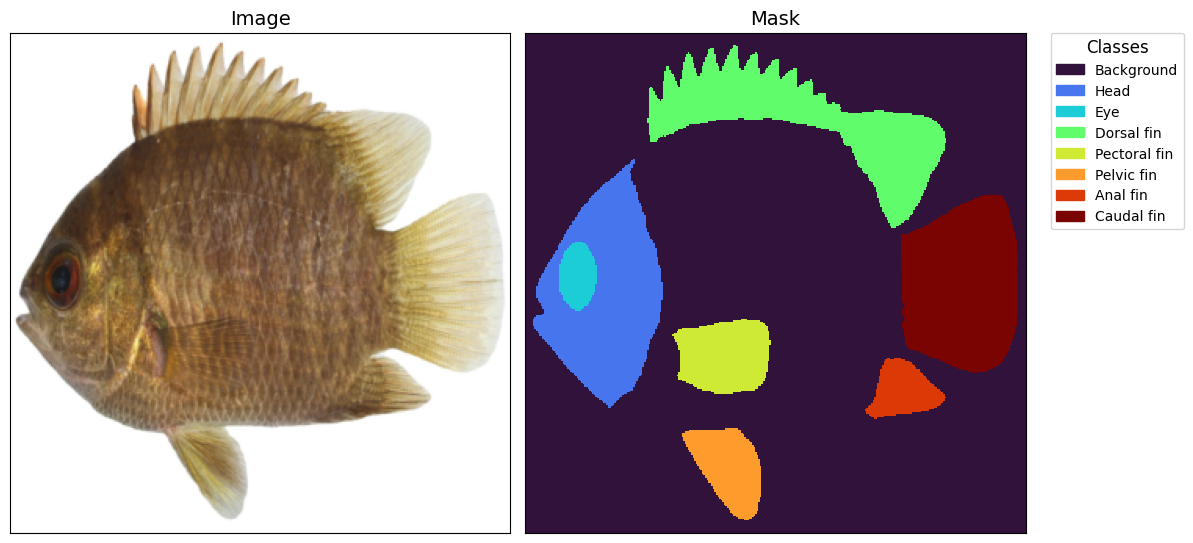

In [10]:
# Get sample image and mask
img, mask, class_id = train_dataset[60]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)

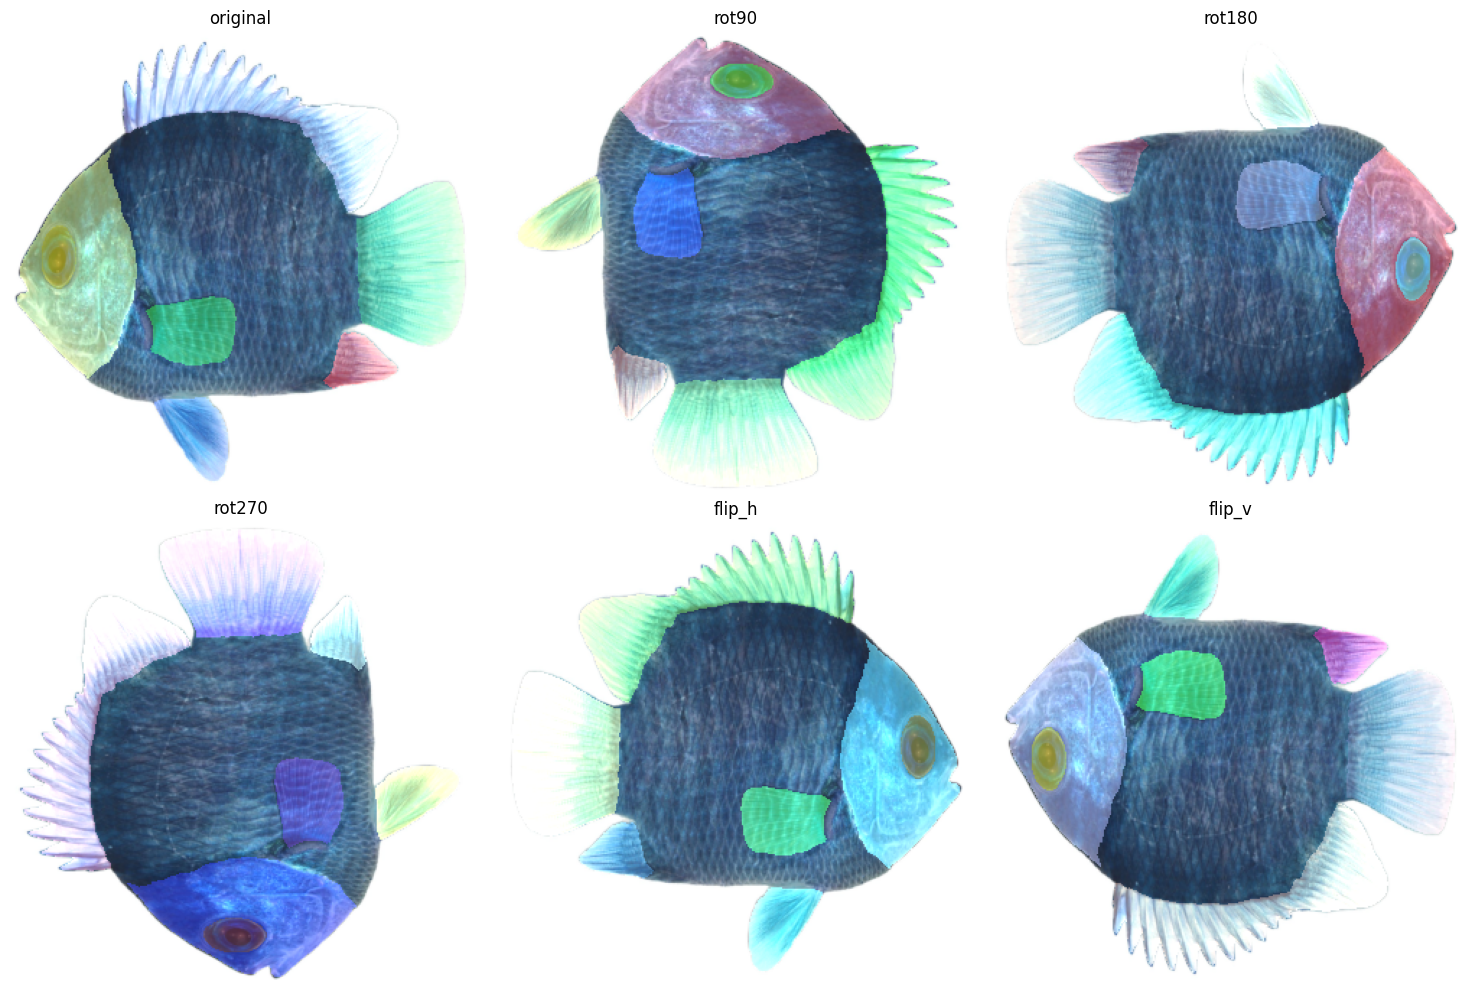

In [11]:
visualize_augmentations(img, mask)

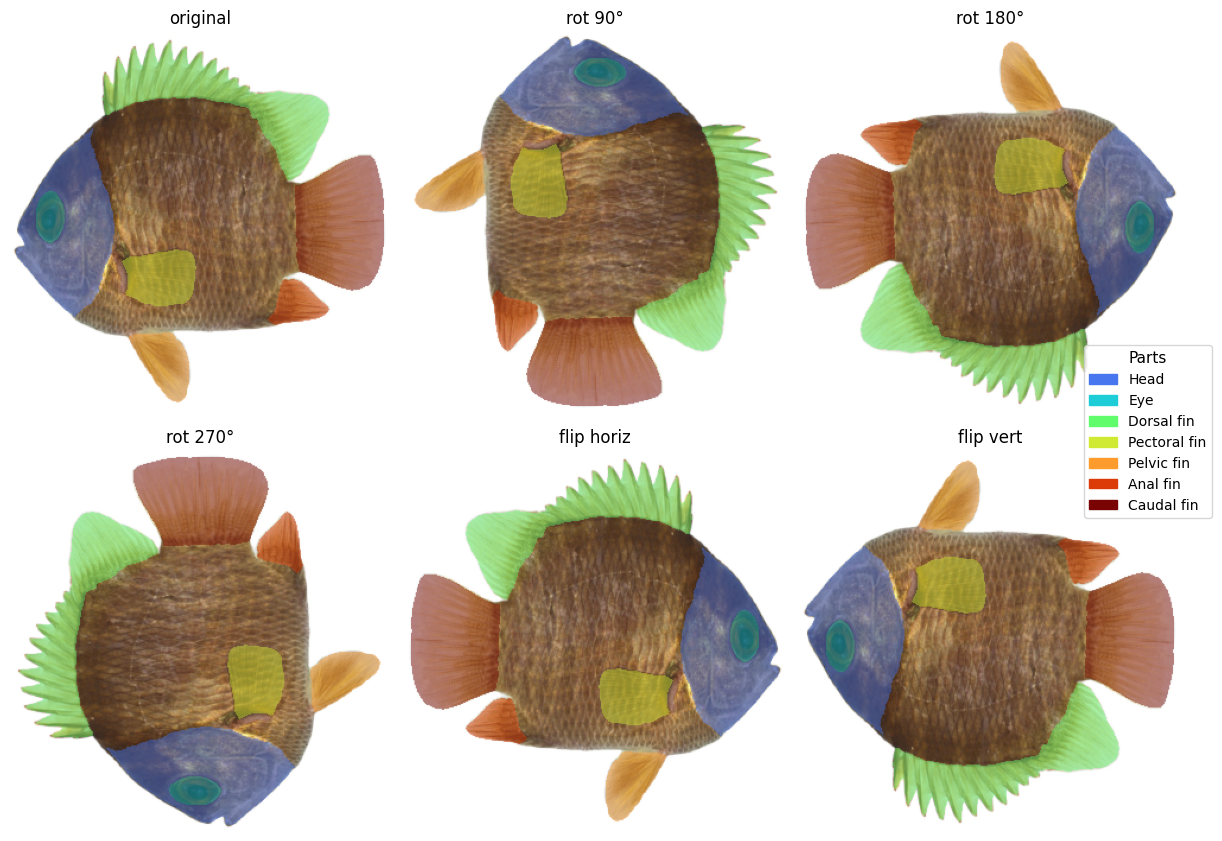

In [14]:
visualize_augmentations_overlay(labels=labels, img_tensor=img, mask_tensor=mask)

In [15]:
# ---------------------------------------------------
# DATASET-BASED AUGMENTATION (CLASS FOLDER STRUCTURE)
# ---------------------------------------------------

def augment_dataset_from_dataset(dataset,
                                out_dir,
                                csv_name="segmentation_train_aug.csv",
                                img_ext=".jpg",
                                mask_ext="_m.png"):
    out_img_root = os.path.join(out_dir, "aug_images")
    out_mask_root = os.path.join(out_dir, "aug_masks")
    os.makedirs(out_img_root, exist_ok=True)
    os.makedirs(out_mask_root, exist_ok=True)

    transforms_list = [
        ("orig", None),
        ("rot90", "rot90"),
        ("rot180", "rot180"),
        ("rot270", "rot270"),
        ("flip_h", "flip_h"),
        ("flip_v", "flip_v"),
    ]
    print(f"Found {len(dataset)} samples in dataset")
    records = []

    for idx in tqdm(range(len(dataset))):

        img, mask, cls_label = dataset[idx]

        # Convert to numpy
        img = to_numpy_image(img)
        mask = to_numpy_mask(mask)

        base_name = dataset.image_names[idx]

        for suffix, tf in transforms_list:
            if tf is None:
                img_t, mask_t = img, mask
            else:
                img_t, mask_t = apply_transform(img, mask, tf)

            new_img_name = f"{base_name}_{suffix}{img_ext}"
            new_mask_name = f"{base_name}_{suffix}{mask_ext}"
            out_img_path = os.path.join(out_img_root, new_img_name)
            out_mask_path = os.path.join(out_mask_root, new_mask_name)

            # Save image (RGB → BGR for cv2)
            cv2.imwrite(out_img_path, cv2.cvtColor(img_t, cv2.COLOR_RGB2BGR))

            # Save mask (preserve labels)
            cv2.imwrite(out_mask_path, mask_t)

            # ---- Add record ----
            records.append({
                "filename": new_img_name,
                "mask_filename": new_mask_name,
                "standardized_species": cls_label
            })
    
    # ---- Create dataframe ----
    df_aug = pd.DataFrame(records)

    csv_path = os.path.join(out_dir, csv_name)
    df_aug.to_csv(csv_path, index=False)

    print(
        f"\n✅ Augmentation complete.\n"
        f"Saved images in: {out_img_root}\n"
        f"Saved masks in:  {out_mask_root}\n"
        f"CSV saved at: {csv_path}\n"
        f"Total expected files: {len(dataset)} x {len(transforms_list)} = {len(dataset)*len(transforms_list)}"
    )

In [16]:
augment_dataset_from_dataset(
    dataset=train_dataset,
    out_dir=DATA_DIR
)

Found 4312 samples in dataset


100%|██████████| 4312/4312 [25:45<00:00,  2.79it/s]


✅ Augmentation complete.
Saved images in: /home/c/choton/beemachine/datasets/Others/fish-vista/aug_images
Saved masks in:  /home/c/choton/beemachine/datasets/Others/fish-vista/aug_masks
CSV saved at: /home/c/choton/beemachine/datasets/Others/fish-vista/segmentation_train_aug.csv
Total expected files: 4312 x 6 = 25872
